<div style="font-family:'Georgia','Times New Roman',Times,serif; width:80%; margin:20px auto; padding:10px 20px 20px 20px; background:#ffffff; border-left:20px solid #003366; box-shadow:0 5px 20px rgba(0,0,0,0.1); text-align:center; border-radius:8px;">

  <div style="display:flex; align-items:center; justify-content:center; gap:20px; margin-bottom:15px; padding-bottom:1px; border-bottom:2px solid #eeeeee;">
    <img src="assets/Logotipo_de_la_Universidad_Nacional_de_Colombia.svg.png" alt="Logo Universidad" style="max-width:80px; height:auto;">
    <div style="font-size:1.1em; color:#003366; font-weight:bold; text-align:left;">Universidad Nacional de Colombia</div>
  </div>

  <h1 style="color:#003366; font-size:2.2em; margin:0.6em 0; font-weight:bold; line-height:1.2;">Detección de enfermedades en plantas de maíz y fríjol común con Inteligencia Artificial e imágenes multiespectrales</h1>
  <h2 style="color:#444444; font-size:1.4em; margin-bottom:0.8em; font-weight:normal; font-style:italic;">Entrenamiento de red neuronal densa con datos de maíz</h2>

  <div style="margin-bottom:0em; font-size:1.1em; color:#222222;">
    <p style="text-align:center; margin:0;"><strong>Autor:</strong> Selene Solano Vera</p>
  </div>

  <div style="margin:1.0em 0 1.0em 0; padding:0.8em 0; color:#666666; font-size:1em;">Medellín, Febrero de 2026</div>

  <div style="height:0.1rem;"></div>

</div>

# Utilidades y Configuración Inicial

Esta sección incluye la importación de bibliotecas necesarias para el entrenamiento de una red neuronal profunda (DNN) con TensorFlow/Keras para la clasificación de deficiencia de nitrógeno en plantas de maíz.

In [2]:
# TensorFlow y Keras para construcción y entrenamiento de redes neuronales
import tensorflow as tf                     
from tensorflow.keras import Model          

# Manipulación de datos
import pandas as pd                         
import numpy as np                          
import pickle                               
import warnings
import joblib                             

# Visualizaciones
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn para preprocesamiento y evaluación
from sklearn.model_selection import train_test_split    
from sklearn.preprocessing import StandardScaler        
from sklearn.preprocessing import LabelEncoder          
from sklearn.metrics import accuracy_score              
from sklearn.metrics import precision_score             
from sklearn.metrics import f1_score                    
from sklearn.metrics import cohen_kappa_score           
from sklearn.metrics import confusion_matrix            
from sklearn.metrics import classification_report       
from sklearn.metrics import ConfusionMatrixDisplay   

In [3]:
# Configuración del tema visual de seaborn
sns.set_theme(style="whitegrid", palette="viridis")

# Configuración de parámetros globales de matplotlib
plt.rcParams['figure.figsize'] = (12, 7)    # Tamaño de figura predeterminado en pulgadas
plt.rcParams['axes.titlesize'] = 18         # Tamaño de fuente para títulos
plt.rcParams['axes.labelsize'] = 14         # Tamaño de fuente para etiquetas de ejes

# Suprimir advertencias para mantener limpia la salida del notebook
warnings.filterwarnings('ignore')

# 1. Carga de dataset

Se cargan los conjuntos de entrenamiento y prueba de plantas de maíz generados por `build_dataset_v2.ipynb`. El split está definido a nivel de objeto (planta), garantizando que todos los píxeles de un mismo objeto pertenezcan al mismo conjunto.

In [4]:
# Carga del dataset de entrenamiento y prueba (split por objeto desde build_dataset_v2)
df_train = pd.read_csv("datasets/dataset_maiz_fix_obj_train_v2.csv")
df_test  = pd.read_csv("datasets/dataset_maiz_fix_obj_test_v2.csv")

# Verificación de la estructura y dimensiones del dataset
print(f"Train shape: {df_train.shape}")
print(f"Test shape:  {df_test.shape}")
print(f"Columnas: {df_train.columns.tolist()}")
print(f"\nDistribución de la clase objetivo (train):")
print(df_train['tratamiento'].value_counts().sort_index())
print(f"\nDistribución de la clase objetivo (test):")
print(df_test['tratamiento'].value_counts().sort_index())

Train shape: (26561080, 8)
Test shape:  (12050590, 8)
Columnas: ['pixel_relativo_x', 'pixel_relativo_y', 'intensidad', 'genotipo', 'tratamiento', 'banda', 'object_id', 'split']

Distribución de la clase objetivo (train):
tratamiento
1    8760890
2    7445120
3    4661850
4    5693220
Name: count, dtype: int64

Distribución de la clase objetivo (test):
tratamiento
1    3450760
2    4322840
3    2233900
4    2043090
Name: count, dtype: int64


# 2. preparación de los datos

Esta fase comprende la transformación de los datos crudos al formato requerido por la red neuronal.

## 2.1 Codificación de la clase objetivo

Las redes neuronales requieren que las etiquetas de clase sean enteros consecutivos comenzando desde 0. Se utiliza `LabelEncoder` para transformar los tratamientos [1, 2, 3, 4] a [0, 1, 2, 3]. El ajuste se realiza únicamente con los datos de entrenamiento.

In [5]:
# Definición de características predictoras
feature_columns = ['pixel_relativo_x', 'pixel_relativo_y', 'intensidad', 'genotipo', 'banda']
X_train = df_train[feature_columns].values  # Matriz de características de entrenamiento
X_test  = df_test[feature_columns].values   # Matriz de características de prueba

y_train_raw = df_train['tratamiento'].values
y_test_raw  = df_test['tratamiento'].values

print(f"Train features shape: {X_train.shape}")
print(f"Test features shape:  {X_test.shape}")

# Encode labels (tratamiento: 1,2,3,4 -> 0,1,2,3 for neural network)
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train_raw)
y_test  = label_encoder.transform(y_test_raw)

print(f"Original labels: {np.unique(y_train_raw)}")
print(f"Encoded labels: {np.unique(y_train)}")
print(f"Label mapping: {dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))}")

Train features shape: (26561080, 5)
Test features shape:  (12050590, 5)
Original labels: [1 2 3 4]
Encoded labels: [0 1 2 3]
Label mapping: {np.int64(1): 0, np.int64(2): 1, np.int64(3): 2, np.int64(4): 3}


## 2.2 Verificación del split

El split train/test ya está definido en los archivos CSV generados por `build_dataset_v2.ipynb` (70% train / 30% test, particionado a nivel de objeto).

In [6]:
# Verificación de los conjuntos ya cargados desde build_dataset_v2
print(f"Training set - Features: {X_train.shape}, Labels: {y_train.shape}")
print(f"Test set     - Features: {X_test.shape}, Labels: {y_test.shape}")

print(f"\nTraining set class distribution:")
train_unique, train_counts = np.unique(y_train, return_counts=True)
for class_label, count in zip(train_unique, train_counts):
    print(f"  Class {class_label}: {count} ({count/len(y_train)*100:.1f}%)")

print(f"\nTest set class distribution:")
test_unique, test_counts = np.unique(y_test, return_counts=True)
for class_label, count in zip(test_unique, test_counts):
    print(f"  Class {class_label}: {count} ({count/len(y_test)*100:.1f}%)")

Training set - Features: (26561080, 5), Labels: (26561080,)
Test set     - Features: (12050590, 5), Labels: (12050590,)

Training set class distribution:


  Class 0: 8760890 (33.0%)
  Class 1: 7445120 (28.0%)
  Class 2: 4661850 (17.6%)
  Class 3: 5693220 (21.4%)

Test set class distribution:
  Class 0: 3450760 (28.6%)
  Class 1: 4322840 (35.9%)
  Class 2: 2233900 (18.5%)
  Class 3: 2043090 (17.0%)


## 2.3 Estandarización de características

In [7]:
# Inicialización y aplicación del estandarizador
scaler = StandardScaler()

# Ajuste con datos de entrenamiento y transformación
X_train_scaled = scaler.fit_transform(X_train)
# Transformación del conjunto de prueba usando los mismos parámetros
X_test_scaled = scaler.transform(X_test)

# Conversión a tipos de datos compatibles con TensorFlow
X_train_scaled = X_train_scaled.astype(np.float32)
X_test_scaled = X_test_scaled.astype(np.float32)
y_train = y_train.astype(np.int32)
y_test = y_test.astype(np.int32)

print(f"\nData types after conversion:")
print(f"X_train: {X_train_scaled.dtype}, y_train: {y_train.dtype}")
print(f"X_test: {X_test_scaled.dtype}, y_test: {y_test.dtype}")


Data types after conversion:
X_train: float32, y_train: int32
X_test: float32, y_test: int32


## 2.3 Convertir a formato dataset de TensorFlow

In [8]:
# Definición del tamaño de batch para el entrenamiento
BATCH_SIZE = 1000 # Número de muestras procesadas simultáneamente

# Creación del dataset de entrenamiento con optimizaciones
train_ds = tf.data.Dataset.from_tensor_slices((X_train_scaled, y_train))
train_ds = train_ds.shuffle(buffer_size=10000, seed=42) # Mezcla con buffer para aleatoriedad  
train_ds = train_ds.batch(BATCH_SIZE)                   # Agrupa en batches
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)          # Carga anticipada automática

# Creación del dataset de prueba (sin shuffling)
test_ds = tf.data.Dataset.from_tensor_slices((X_test_scaled, y_test))
test_ds = test_ds.batch(BATCH_SIZE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

print(f"Training dataset created with batch size: {BATCH_SIZE}")
print(f"Test dataset created with batch size: {BATCH_SIZE}")

# Verificación de la estructura del dataset
for batch_features, batch_labels in train_ds.take(1):
    print(f"\nBatch verification:")
    print(f"Features batch shape: {batch_features.shape}")
    print(f"Labels batch shape: {batch_labels.shape}")
    print(f"Features dtype: {batch_features.dtype}")
    print(f"Labels dtype: {batch_labels.dtype}")
    break

Training dataset created with batch size: 1000
Test dataset created with batch size: 1000

Batch verification:
Features batch shape: (1000, 5)
Labels batch shape: (1000,)
Features dtype: <dtype: 'float32'>
Labels dtype: <dtype: 'int32'>


# 3. Construcción de la Arquitectura de Red Neuronal

Se implementa una Red Neuronal Profunda (Deep Neural Network - DNN) utilizando la API funcional de Keras. 

In [9]:
class InitialModel(Model):
  def __init__(self, input_shape=(5,), num_classes=4, **kwargs):
    super(InitialModel, self).__init__(**kwargs)
    self.input_shape_val = input_shape
    self.num_classes = num_classes

    # Input layer
    self.input_layer = tf.keras.layers.InputLayer(input_shape=input_shape)
    
    # First hidden layer
    self.dense1 = tf.keras.layers.Dense(512, activation='relu')

    # Second hidden layer
    self.dense2 = tf.keras.layers.Dense(256, activation='relu')

    # Second hidden layer
    self.dense3 = tf.keras.layers.Dense(128, activation='relu')

     # Second hidden layer
    self.dense4 = tf.keras.layers.Dense(128, activation='relu')

    # Third hidden layer
    self.dense5 = tf.keras.layers.Dense(64, activation='relu')
    
    # Output layer
    self.out = tf.keras.layers.Dense(num_classes, activation='softmax')

  def call(self, inputs, training=None):
    
    x = self.dense1(inputs)
    x = self.dense2(x)
    x = self.dense3(x)
    x = self.dense4(x)
    x = self.dense5(x)
    return self.out(x)

def get_config(self):
    config = super(InitialModel, self).get_config()
    config.update({
        "input_shape": self.input_shape_val,
        "num_classes": self.num_classes,
    })
    return config

# Instanciar el modelo
model = InitialModel(input_shape=(5,), num_classes=4)

In [10]:
# Definición de la función de pérdida y optimizador
loss_object = tf.keras.losses.SparseCategoricalCrossentropy()   # Para clasificación multiclase con etiquetas enteras
optimizer = tf.keras.optimizers.Adam()                          # Optimizador Adam con learning rate adaptativo

In [11]:
# Definición de métricas para monitorear el entrenamiento
train_loss = tf.keras.metrics.Mean(name='train_loss')                               # Pérdida promedio de entrenamiento
train_accuracy = tf.keras.metrics.SparseCategoricalAccuracy(name='train_accuracy')  # Exactitud de entrenamiento

test_loss = tf.keras.metrics.Mean(name='test_loss')                                 # Pérdida promedio de validación
test_accuracy = tf.keras.metrics.SparseCategoricalAccuracy(name='test_accuracy')    # Exactitud de validación

In [12]:
# Implementación manual de callbacks para control del entrenamiento

best_val_loss = float('inf')   # Mejor pérdida de validación observada
best_weights = None            # Pesos del modelo con mejor rendimiento
patience_lr = 3                # Épocas sin mejora antes de reducir LR
patience_es = 4                # Épocas sin mejora antes de detener entrenamiento
lr_counter = 0                 # Contador para reducción de LR
es_counter = 0                 # Contador para early stopping
lr_factor = 0.2                # Factor de reducción del learning rate (nuevo_lr = lr × 0.2)
min_lr = 0.00001               # Learning rate mínimo permitido

print("Manual callbacks initialized:")
print(f"  LR reduction: patience={patience_lr}, factor={lr_factor}, min_lr={min_lr}")
print(f"  Early stopping: patience={patience_es}, restore_best_weights=True")

Manual callbacks initialized:
  LR reduction: patience=3, factor=0.2, min_lr=1e-05
  Early stopping: patience=4, restore_best_weights=True


# 4. Entrenamiento del Modelo

Esta sección implementa el loop de entrenamiento personalizado con TensorFlow.

In [13]:
@tf.function
def train_step(data, labels):
  """
  Ejecuta un paso de entrenamiento: forward pass, cálculo de pérdida y backpropagation.
  
  Args:
    data: Batch de características de entrada
    labels: Batch de etiquetas verdaderas
  """
  with tf.GradientTape() as tape:
    predictions = model(data, training=True)  # Forward pass con modo entrenamiento
    loss = loss_object(labels, predictions)   # Cálculo de pérdida
  gradients = tape.gradient(loss, model.trainable_variables)  # Backpropagation
  optimizer.apply_gradients(zip(gradients, model.trainable_variables))  # Actualización de pesos

  train_loss(loss)                     # Actualización de métrica de pérdida
  train_accuracy(labels, predictions)  # Actualización de métrica de exactitud

In [14]:
@tf.function
def test_step(data, labels):
  """
  Ejecuta evaluación en conjunto de validación/prueba sin actualización de pesos.
  
  Args:
    data: Batch de características de entrada
    labels: Batch de etiquetas verdaderas
  """
  predictions = model(data, training=False)  # Forward pass sin dropout/regularización
  t_loss = loss_object(labels, predictions)  # Cálculo de pérdida

  test_loss(t_loss)                   # Actualización de métrica de pérdida
  test_accuracy(labels, predictions)  # Actualización de métrica de exactitud

In [15]:
EPOCHS = 100

train_batches = len(X_train_scaled) // BATCH_SIZE + (1 if len(X_train_scaled) % BATCH_SIZE != 0 else 0)
test_batches = len(X_test_scaled) // BATCH_SIZE + (1 if len(X_test_scaled) % BATCH_SIZE != 0 else 0)

print(f"Training for up to {EPOCHS} epochs (with early stopping)")
print(f"Training batches per epoch: {train_batches}")
print(f"Test batches per epoch: {test_batches}")

# Resetear métricasa antes del entrenamiento
train_loss.reset_state()
train_accuracy.reset_state()
test_loss.reset_state()
test_accuracy.reset_state()

for epoch in range(EPOCHS):
  print(f"\nEpoch {epoch+1}/{EPOCHS}")
  
  # Entrenamiento
  for batch_idx, (data, labels) in enumerate(train_ds):
    train_step(data, labels)

  # Prueba
  for test_data, test_labels in test_ds:
    test_step(test_data, test_labels)

  # Obtener métricas actuales
  current_train_loss = train_loss.result().numpy()
  current_train_acc = train_accuracy.result().numpy() * 100
  current_test_loss = test_loss.result().numpy()
  current_test_acc = test_accuracy.result().numpy() * 100
  current_lr = optimizer.learning_rate.numpy()

  # Resultados épocas
  template = 'Epoch {}, Loss: {:.4f}, Accuracy: {:.2f}%, Test Loss: {:.4f}, Test Accuracy: {:.2f}%, LR: {:.6f}'
  print(template.format(epoch+1,
                        current_train_loss,
                        current_train_acc,
                        current_test_loss,
                        current_test_acc,
                        current_lr))

  # Verificar si la pérdida en validación mejora
  if current_test_loss < best_val_loss:
    print(f"  ✓ Validation loss improved from {best_val_loss:.4f} to {current_test_loss:.4f}")
    best_val_loss = current_test_loss
    best_weights = model.get_weights()  # Salvar mejores pesos
    lr_counter = 0  # Resetear contador LR
    es_counter = 0  # Resetear contador early stopping
  else:
    lr_counter += 1
    es_counter += 1
    print(f"  ✗ Validation loss did not improve (best: {best_val_loss:.4f})")
    
     # Reducción del Learning rate
    if lr_counter >= patience_lr:
      old_lr = optimizer.learning_rate.numpy()
      new_lr = max(old_lr * lr_factor, min_lr)
      if new_lr != old_lr:
        optimizer.learning_rate.assign(new_lr)
        print(f"  → Reducing learning rate from {old_lr:.6f} to {new_lr:.6f}")
        lr_counter = 0  # Resetear contador LR
      else:
        print(f"  → Learning rate already at minimum ({min_lr:.6f})")
    
    # Lógica de Early stopping
    if es_counter >= patience_es:
      print(f"\n⚠ Early stopping triggered! No improvement for {patience_es} epochs.")
      print(f"  Restoring best weights from epoch {epoch+1-patience_es}")
      model.set_weights(best_weights)  # Restaurar lo pesos
      break

  # Resetear las métricas para la siguiente época
  train_loss.reset_state()
  train_accuracy.reset_state()
  test_loss.reset_state()
  test_accuracy.reset_state()

print("\nTraining completed!")
print(f"Best validation loss: {best_val_loss:.4f}")

Training for up to 100 epochs (with early stopping)
Training batches per epoch: 26562
Test batches per epoch: 12051

Epoch 1/100
Epoch 1, Loss: 0.1108, Accuracy: 97.79%, Test Loss: 59.1917, Test Accuracy: 35.87%, LR: 0.001000
  ✓ Validation loss improved from inf to 59.1917

Epoch 2/100
Epoch 2, Loss: 0.1899, Accuracy: 95.93%, Test Loss: 33.5150, Test Accuracy: 32.69%, LR: 0.001000
  ✓ Validation loss improved from 59.1917 to 33.5150

Epoch 3/100
Epoch 3, Loss: 0.1692, Accuracy: 95.14%, Test Loss: 56.7726, Test Accuracy: 32.63%, LR: 0.001000
  ✗ Validation loss did not improve (best: 33.5150)

Epoch 4/100
Epoch 4, Loss: 0.1755, Accuracy: 93.79%, Test Loss: 79.0061, Test Accuracy: 35.29%, LR: 0.001000
  ✗ Validation loss did not improve (best: 33.5150)

Epoch 5/100
Epoch 5, Loss: 0.1831, Accuracy: 94.98%, Test Loss: 68.2002, Test Accuracy: 35.87%, LR: 0.001000
  ✗ Validation loss did not improve (best: 33.5150)
  → Reducing learning rate from 0.001000 to 0.000200

Epoch 6/100
Epoch 6, L

## 4.1 Guardar modelo

In [16]:
# Guardar el modelo entrenado en formato Keras nativo
model.save("models/maiz/maiz_model_dnn_v2.keras")
print("Model saved successfully as 'frijol_model.keras'")

# Guardar objetos de preprocesamiento (scaler, encoder) para uso en producción
with open('preprocessing_objects_maiz.pkl', 'wb') as f:
    pickle.dump({
        'scaler': scaler,                   # Estandarizador ajustado
        'label_encoder': label_encoder,     # Codificador de etiquetas
        'feature_columns': feature_columns  # Lista de características esperadas
    }, f)

print("Preprocessing objects saved as 'preprocessing_objects.pkl'")

Model saved successfully as 'frijol_model.keras'
Preprocessing objects saved as 'preprocessing_objects.pkl'


# 5. Evaluación del Modelo

Esta sección carga el modelo entrenado y evalúa su rendimiento mediante:
- **Generación de predicciones**: En conjuntos de entrenamiento y prueba
- **Métricas de clasificación**: Accuracy, Precision, F1-Score, Kappa
- **Matrices de confusión**: Visualización de aciertos y errores por clase
- **Análisis de curvas de aprendizaje**: Evolución de pérdida y exactitud durante entrenamiento

In [17]:
# Carga del modelo entrenado desde archivo
trained_model = tf.keras.models.load_model('models/maiz/maiz_model_dnn_v2.keras', custom_objects={'InitialModel': InitialModel})

In [18]:
# Generación de predicciones en el conjunto de prueba
print("Realizando predicciones en Test...")
y_pred_probs = trained_model.predict(X_test_scaled)  # Probabilidades para cada clase
y_pred = np.argmax(y_pred_probs, axis=1)

# Realizar predicciones en el conjunto de entrenamiento
print("Realizando predicciones en Train...")
y_train_pred_probs = trained_model.predict(X_train_scaled)
y_train_pred = np.argmax(y_train_pred_probs, axis=1)

Realizando predicciones en Test...
376581/376581 ━━━━━━━━━━━━━━━━━━━━ 286s 760us/step
Realizando predicciones en Train...
830034/830034 ━━━━━━━━━━━━━━━━━━━━ 1510s 2ms/step


## 5.1. Guardar predicciones

In [19]:
# Guardar predicciones del conjunto de prueba
joblib.dump(y_pred, "results/predictions/maiz/test/predicciones_dnn_test_v2.pkl")
print("✓ Predicciones de prueba guardadas en: results/predictions/maiz/test/predicciones_dnn_test_v2.pkl")

# Guardar predicciones del conjunto de entrenamiento
joblib.dump(y_train_pred, "results/predictions/maiz/train/predicciones_dnn_train_v2.pkl")
print("✓ Predicciones de entrenamiento guardadas en: results/predictions/maiz/train/predicciones_dnn_train_v2.pkl")

# Guardar probabilidades predichas
joblib.dump(y_pred_probs, "results/predictions/maiz/test/predicciones_dnn_test_probs_v2.pkl")
joblib.dump(y_train_pred_probs, "results/predictions/maiz/train/predicciones_dnn_train_probs_v2.pkl")
print("✓ Probabilidades de predicción guardadas exitosamente")

✓ Predicciones de prueba guardadas en: results/predictions/maiz/test/predicciones_dnn_test_v2.pkl
✓ Predicciones de entrenamiento guardadas en: results/predictions/maiz/train/predicciones_dnn_train_v2.pkl
✓ Probabilidades de predicción guardadas exitosamente


# 6. Resultados

In [20]:
# Cálculo de métricas para el conjunto de prueba (Test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
kappa = cohen_kappa_score(y_test, y_pred)

# Cálculo de métricas para el conjunto de entrenamiento (Train)
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred, average='weighted')
train_f1 = f1_score(y_train, y_train_pred, average='weighted')
train_kappa = cohen_kappa_score(y_train, y_train_pred)

# Presentación comparativa de métricas
print("-" * 65)
print(f"{'Métrica':<20} | {'Train':<20} | {'Test':<20}")
print("-" * 65)
print(f"{'Accuracy':<20} | {train_accuracy:<20.4f} | {accuracy:<20.4f}")
print(f"{'Precision':<20} | {train_precision:<20.4f} | {precision:<20.4f}")
print(f"{'F1-Score':<20} | {train_f1:<20.4f} | {f1:<20.4f}")
print(f"{'Kappa Score':<20} | {train_kappa:<20.4f} | {kappa:<20.4f}")
print("-" * 65)

-----------------------------------------------------------------
Métrica              | Train                | Test                
-----------------------------------------------------------------
Accuracy             | 0.2853               | 0.3543              
Precision            | 0.2551               | 0.2280              
F1-Score             | 0.1429               | 0.2031              
Kappa Score          | 0.0060               | -0.0014             
-----------------------------------------------------------------


In [21]:
# Obtención de nombres de clases para los reportes
target_names = label_encoder.classes_.astype(str)

# Reporte de clasificación para conjunto de prueba
print("\nReporte de Clasificación (Test):")
print(classification_report(y_test, y_pred, target_names=target_names))

# Reporte de clasificación para conjunto de entrenamiento
print("\nReporte de Clasificación (Train):")
print(classification_report(y_train, y_train_pred, target_names=target_names))


Reporte de Clasificación (Test):
              precision    recall  f1-score   support

           1       0.23      0.02      0.04   3450760
           2       0.36      0.96      0.52   4322840
           3       0.00      0.00      0.00   2233900
           4       0.19      0.01      0.02   2043090

    accuracy                           0.35  12050590
   macro avg       0.20      0.25      0.15  12050590
weighted avg       0.23      0.35      0.20  12050590


Reporte de Clasificación (Train):
              precision    recall  f1-score   support

           1       0.33      0.02      0.04   8760890
           2       0.28      0.98      0.44   7445120
           3       0.00      0.00      0.00   4661850
           4       0.31      0.01      0.02   5693220

    accuracy                           0.29  26561080
   macro avg       0.23      0.25      0.13  26561080
weighted avg       0.26      0.29      0.14  26561080



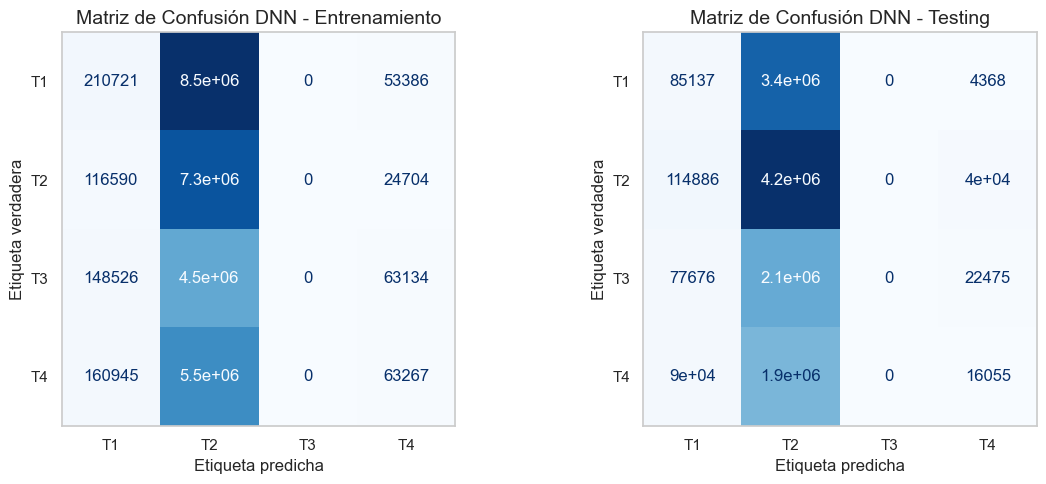

In [22]:
# Visualización comparativa de matrices de confusión
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
tratamiento_labels = ['T1', 'T2', 'T3', 'T4']

# Matriz de confusión para conjunto de entrenamiento
cm_train = confusion_matrix(y_train, y_train_pred)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=tratamiento_labels)
disp_train.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de Confusión DNN - Entrenamiento', fontsize=14)
axes[0].set_xlabel('Etiqueta predicha', fontsize=12)
axes[0].set_ylabel('Etiqueta verdadera', fontsize=12)
axes[0].grid(False)

# Matriz de confusión para conjunto de prueba
cm_test = confusion_matrix(y_test, y_pred)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=tratamiento_labels)
disp_test.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Matriz de Confusión DNN - Testing', fontsize=14)
axes[1].set_xlabel('Etiqueta predicha', fontsize=12)
axes[1].set_ylabel('Etiqueta verdadera', fontsize=12)
axes[1].grid(False)

plt.tight_layout()
plt.show()